<a href="https://colab.research.google.com/github/MoeinRajabiGhaemiyeh/IMDB-Market-Basket-Analysis/blob/main/Market_Basket_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Market-Basket Analysis of the IMDB Top 1000 Dataset

### Distributed Frequent Itemset Mining using PySpark

Moein Rajabi Ghaemiyeh

Algorithms for Massive Data

Instructor: Prof. Malchiodi



## Setup and Configuration

In [ ]:
import os

!apt-get install openjdk-17-jdk-headless -qq > /dev/null
!wget -q http://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz
!pip install -q findspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

In [2]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark

In [3]:
sc = spark.sparkContext

In [4]:
os.environ['KAGGLE_USERNAME'] = "xxxxxx"
os.environ['KAGGLE_KEY'] = "xxxxxx"
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows --unzip

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
100% 175k/175k [00:00<00:00, 32.5MB/s]



## Functions

In [5]:
from itertools import combinations
from pyspark.sql.functions import lower, trim, col, array, expr, size, array_distinct

def sample_density(rdd, fraction, seed = None):

  # Checks the density of actual pairs in a fraction of dataset
  # Density is used for choosing the best method of saving pair counts

  sample_rdd = rdd.sample(withReplacement = False, fraction = fraction, seed = seed)
  unique_actors_count = sample_rdd.flatMap(lambda x: x).distinct().count()
  max_possible_pairs = (unique_actors_count * (unique_actors_count - 1)) / 2
  actual_unique_pairs = (
      sample_rdd.flatMap(lambda x: [tuple(sorted([x[i], x[j]])) for i in range(len(x)-1) for j in range(i+1, len(x))])
      .distinct()
      .count()
  )
  density_ratio = actual_unique_pairs / max_possible_pairs
  return density_ratio

def counting(data_rdd, min_support):

  # Counts item occurrences in an RDD.
  # Filters out any items that do not meet the minimum support threshold.

  return (
      data_rdd.flatMap(lambda x: x)
      .map(lambda x: (x, 1))
      .reduceByKey(lambda x, y: x + y)
      .filter(lambda x: x[1] >= min_support)
      )

def frequent_pairs(data_rdd, frequent_items, min_support):

  # Generates candidate pairs and counts length-2 frequent pairs using a manual nested loop.
  # Uses a broadcast variable to efficiently filter out non-frequent items.

  frequent_items_bc = sc.broadcast(set(frequent_items))
  two_pairs_candidates = data_rdd.map(lambda x: [i for i in x if i in frequent_items_bc.value]) # Keep only actors that passed the L1 support threshold.
  frequent_pairs = two_pairs_candidates.map(lambda x: [tuple(sorted([x[i], x[j]])) for i in range(len(x) - 1) for j in range(i + 1, len(x))]) # Manually generate all possible unique pairs from the remaining actors.
  return counting(frequent_pairs, min_support)

def frequent_dict(data_rdd):

  # Generates a dictionary with frequent items as keys and their counts as values.

  return dict(sorted(data_rdd.collect()))

def k_length_candidates(frequent_k_minus_1, k):

  # Generates k-length candidates using Apriori logic.
  # Combines frequent (k-1)-length items to create candidates and prunes those ones that have a subset which is not frequent.

  frequent_k_minus_1 = list(frequent_k_minus_1)
  frequent_set = set(frequent_k_minus_1)
  candidates = []
  for i in range(len(frequent_k_minus_1) - 1):
    item1 = frequent_k_minus_1[i]
    for j in range(i + 1, len(frequent_k_minus_1)):
      item2 = frequent_k_minus_1[j]
      if item1[:k - 2] != item2[:k - 2]: # Join only if the first k-2 elements match.
        break
      else:
        new_candidate = item1[:k - 2] + (item1[-1], item2[-1])
        flag = 1
        for z in combinations(new_candidate, k - 1): # Ensure all k-1 subsets exist in the frequent set.
          if z not in frequent_set:
            flag = 0
            break
        if flag == 1:
          candidates.append(new_candidate)
  return candidates

def Apriori(data_rdd, min_support):
  # Generates a dictionary consists of all frequent itemsets satisfying minimum threshold.
  # Uses match-case logic to handle counting from signle items to 4-tuples properly.
  frequents_dict = {}
  for counter in range(1, 5):
    match counter:
      case 1:
        imdb_frequent_items = counting(imdb_rdd_id, min_support)
        frequent_items_dict = frequent_dict(imdb_frequent_items)
        frequents_dict = frequent_items_dict
      case 2:
        if len(frequent_items_dict) == 0:
          break
        imdb_frequent_pairs = frequent_pairs(imdb_rdd_id, frequent_items_dict.keys(), min_support)
        frequent_pairs_dict = frequent_dict(imdb_frequent_pairs)
        frequents_dict = frequent_pairs_dict | frequent_items_dict
      case 3:
        if len(frequent_pairs_dict) == 0:
          break
        triple_candidates = k_length_candidates(frequent_pairs_dict.keys(), 3)
        triple_candidates_set = set(triple_candidates)
        if len(triple_candidates_set) == 0:
          break
        # Broadcast valid candidates to optimize combinations lookup
        triple_candidates_bc = sc.broadcast(triple_candidates_set)
        tripled_rdd = imdb_rdd_id.map(lambda x: [triple for triple in combinations(sorted(x), 3) if triple in triple_candidates_bc.value])
        triples = counting(tripled_rdd, min_support)
        frequent_triples_dict = frequent_dict(triples)
        frequents_dict = frequent_triples_dict | frequents_dict
      case 4:
        if len(frequent_triples_dict) == 0:
          break
        four_tuple_candidates = k_length_candidates(frequent_triples_dict.keys(), 4)
        four_tuple_candidates_set = set(four_tuple_candidates)
        if len(four_tuple_candidates_set) == 0:
          break
        four_tuple_candidates_bc = sc.broadcast(four_tuple_candidates_set)
        four_tuple_rdd = imdb_rdd_id.map(lambda x: [tuple(sorted(x))] if len(x) == 4 and tuple(sorted(x)) in four_tuple_candidates_bc.value else [])
        four_tuples = counting(four_tuple_rdd, min_support)
        frequent_four_tuples_dict = frequent_dict(four_tuples)
        frequents_dict = frequent_four_tuples_dict | frequents_dict
  return frequents_dict

def association_rules_generator(frequents_dict, c, min_interest, n, mapping):

  # Generates Association Rules.
  # Parallelizes frequent tuples and calculates Confidence and Interestingness across the Spark cluster.

  itemsets_rdd = sc.parallelize([item for item in frequents_dict.items() if type(item[0]) == tuple]) # Parallelize only tuples (pairs, triples, etc.) as rules require at least 2 items.
  # Broadcast dictionaries so worker nodes can look up counts and map names
  freq_bc = sc.broadcast(frequents_dict)
  mapping_bc = sc.broadcast(mapping)
  def process_itemset(row):
        itemset, numerator = row
        freq_map = freq_bc.value
        names_map = mapping_bc.value
        rules = []

        length = len(itemset)
        for combo_length in range(1, length): # Generate all possible rule combinations (A -> B) for this itemset.
            for combo in combinations(itemset, combo_length):
                left_out = tuple(sorted(set(itemset) - set(combo)))

                # Look up denominators from the broadcasted dictionary.
                # Confidence Calculation
                denom_combo = freq_map[combo] if len(combo) > 1 else freq_map[combo[0]]
                score = numerator / denom_combo

                # Interestingness Calculation
                denom_left = freq_map[left_out] if len(left_out) > 1 else freq_map[left_out[0]]
                interest = abs(score - (denom_left / n))

                # Filter and format valid rules
                if score >= c and interest >= min_interest:
                    A = ', '.join([names_map[id].title() for id in combo])
                    B = ', '.join([names_map[id].title() for id in left_out])
                    rule_str = f"{A:<35} ---> {B:<30}  |   Conf: {score:.2f}  |   Int: {interest:.2f}"
                    # Append as a tuple so can be sorted by interestingness later.
                    rules.append((rule_str, interest))

        return rules
  return (
        itemsets_rdd.flatMap(process_itemset)
        .sortBy(lambda x: x[1], ascending=False) # Sort by interest (index 1) across the cluster.
        .map(lambda x: x[0]) # Drop the raw score, keep only the formatted string.
        .collect()
    )


## Parameters

In [6]:
min_support = 3 # The minimum number of appearance of an itemset to be considered as frequent.
c = 0.8 # The minimum value of confidence so that an association rule is considered valid.
min_interest = 0.7 # The minimum interestingness that is appropriate for exctracting meaningful association rules.
use_subsample = False # If subsampling was needed, this flag should be set to True.
subsample_fraction = 0.1 # If use_subsample = 1, this variable sets the fraction of data needed to run the algorithm.

## Loading Data & Preprocessing

In [7]:
imdb_df = spark.read.csv("imdb_top_1000.csv", header=True, sep=",")

# Selecting necessary columns
imdb_df_short = imdb_df.select(["Star1", "Star2", "Star3", "Star4"])

# Check and Perform subsampling if needed.
if use_subsample:
  imdb_df_short = imdb_df_short.sample(withReplacement = False, fraction = subsample_fraction, seed = 123)

# Lowering and Trimming Star names
imdb_df_short = imdb_df_short.withColumn("Star1", lower(trim(col("Star1"))))
imdb_df_short = imdb_df_short.withColumn("Star2", lower(trim(col("Star2"))))
imdb_df_short = imdb_df_short.withColumn("Star3", lower(trim(col("Star3"))))
imdb_df_short = imdb_df_short.withColumn("Star4", lower(trim(col("Star4"))))

# Merging All Star Columns into one array
imdb_df_short = imdb_df_short.withColumn("Stars", array(col("Star1"), col("Star2"), col("Star3"), col("Star4")))
imdb_df_short = imdb_df_short.drop("Star1", "Star2", "Star3", "Star4")

# Deleting null values from the list of Stars and Filtering out the lists with no actors
imdb_df_short = imdb_df_short.withColumn("Stars", expr("filter(Stars, x -> x is not null)")).filter(size(col("Stars")) > 0)

# Removing duplicated Actors from a moive
imdb_df_short = imdb_df_short.withColumn("Stars", array_distinct("Stars"))

## Implementing RDD

In [8]:
imdb_rdd = imdb_df_short.rdd.map(lambda x: x.Stars)

# Map string names to integers to save memory and network bandwidth during MapReduce
actor_to_id = dict(
    imdb_rdd.flatMap(lambda x: x)
    .distinct()
    .zipWithIndex()
    .collect()
)

# Broadcast the dictionary for efficient access on worker nodes
actor_to_id_bc = sc.broadcast(actor_to_id)
imdb_rdd_id = imdb_rdd.map(lambda x: [actor_to_id_bc.value[actor] for actor in x])

# Reverse mapping dictionary to translate IDs back to strings at the end
id_to_actor = {v: k for k, v in actor_to_id.items()}

# Total number of movies (used for probability calculations)
number_of_baskets = imdb_rdd_id.count()


## Checking Density Ratio

In [9]:
density_ratio = sample_density(imdb_rdd_id, 0.05, seed = 123)
print(f"Density Ratio: {density_ratio:.3f}")

if density_ratio < 0.33:
    print("The data is highly sparse. The Triples Method is superior.")
else:
    print("The data is dense. A Triangular Matrix would save memory.")

Density Ratio: 0.017
The data is highly sparse. The Triples Method is superior.


## Frequent Items

In [14]:
final_result = Apriori(imdb_rdd_id, min_support)


## Association Rules

In [11]:
# Generate and print the highly significant actor collaborations
association_rules = association_rules_generator(final_result, c, min_interest, number_of_baskets, id_to_actor)
for rule in association_rules:
  print(rule)


Elijah Wood                         ---> Ian Mckellen, Orlando Bloom     |   Conf: 1.00  |   Int: 1.00
Orlando Bloom                       ---> Elijah Wood, Ian Mckellen       |   Conf: 1.00  |   Int: 1.00
Elijah Wood, Ian Mckellen           ---> Orlando Bloom                   |   Conf: 1.00  |   Int: 1.00
Ian Mckellen, Orlando Bloom         ---> Elijah Wood                     |   Conf: 1.00  |   Int: 1.00
Mark Hamill                         ---> Harrison Ford, Carrie Fisher    |   Conf: 1.00  |   Int: 1.00
Harrison Ford, Carrie Fisher        ---> Mark Hamill                     |   Conf: 1.00  |   Int: 1.00
Elijah Wood                         ---> Orlando Bloom                   |   Conf: 1.00  |   Int: 1.00
Orlando Bloom                       ---> Elijah Wood                     |   Conf: 1.00  |   Int: 1.00
Mark Hamill, Harrison Ford          ---> Carrie Fisher                   |   Conf: 1.00  |   Int: 1.00
Mark Hamill                         ---> Carrie Fisher                   

## Minimum Support Sensitivity Analysis

In [12]:
import pandas as pd
min_support_df = pd.DataFrame(columns = ["Frequent Items", "Frequent Pairs", "Frequent Triples", "Frequent 4-tuples", "Association Rules"])
for min_support in range(2, 11):
  result = Apriori(imdb_rdd_id, min_support)
  association_rule = association_rules_generator(result, c, min_interest, number_of_baskets, id_to_actor)
  result_rdd = sc.parallelize(result.keys())
  counts = result_rdd.map(lambda x: (len(x), 1) if type(x) == tuple else (1, 1)).reduceByKey(lambda x, y: x + y).map(lambda x: x[1]).collect()[::-1]
  match len(counts):
    case 1:
      counts.append(0)
      counts.append(0)
      counts.append(0)
    case 2:
      counts.append(0)
      counts.append(0)
    case 3:
      counts.append(0)
  counts.append(len(association_rule))
  min_support_df.loc[min_support] = counts
min_support_df.index.name = "Min Support"
min_support_df

,Frequent Items,Frequent Pairs,Frequent Triples,Frequent 4-tuples,Association Rules
Min Support,,,,,
2,641,25,121,4,201
3,272,3,25,0,26
4,142,1,5,0,10
5,78,1,3,0,9
6,58,1,0,0,2
7,30,0,0,0,0
8,17,0,0,0,0
9,15,0,0,0,0
10,9,0,0,0,0


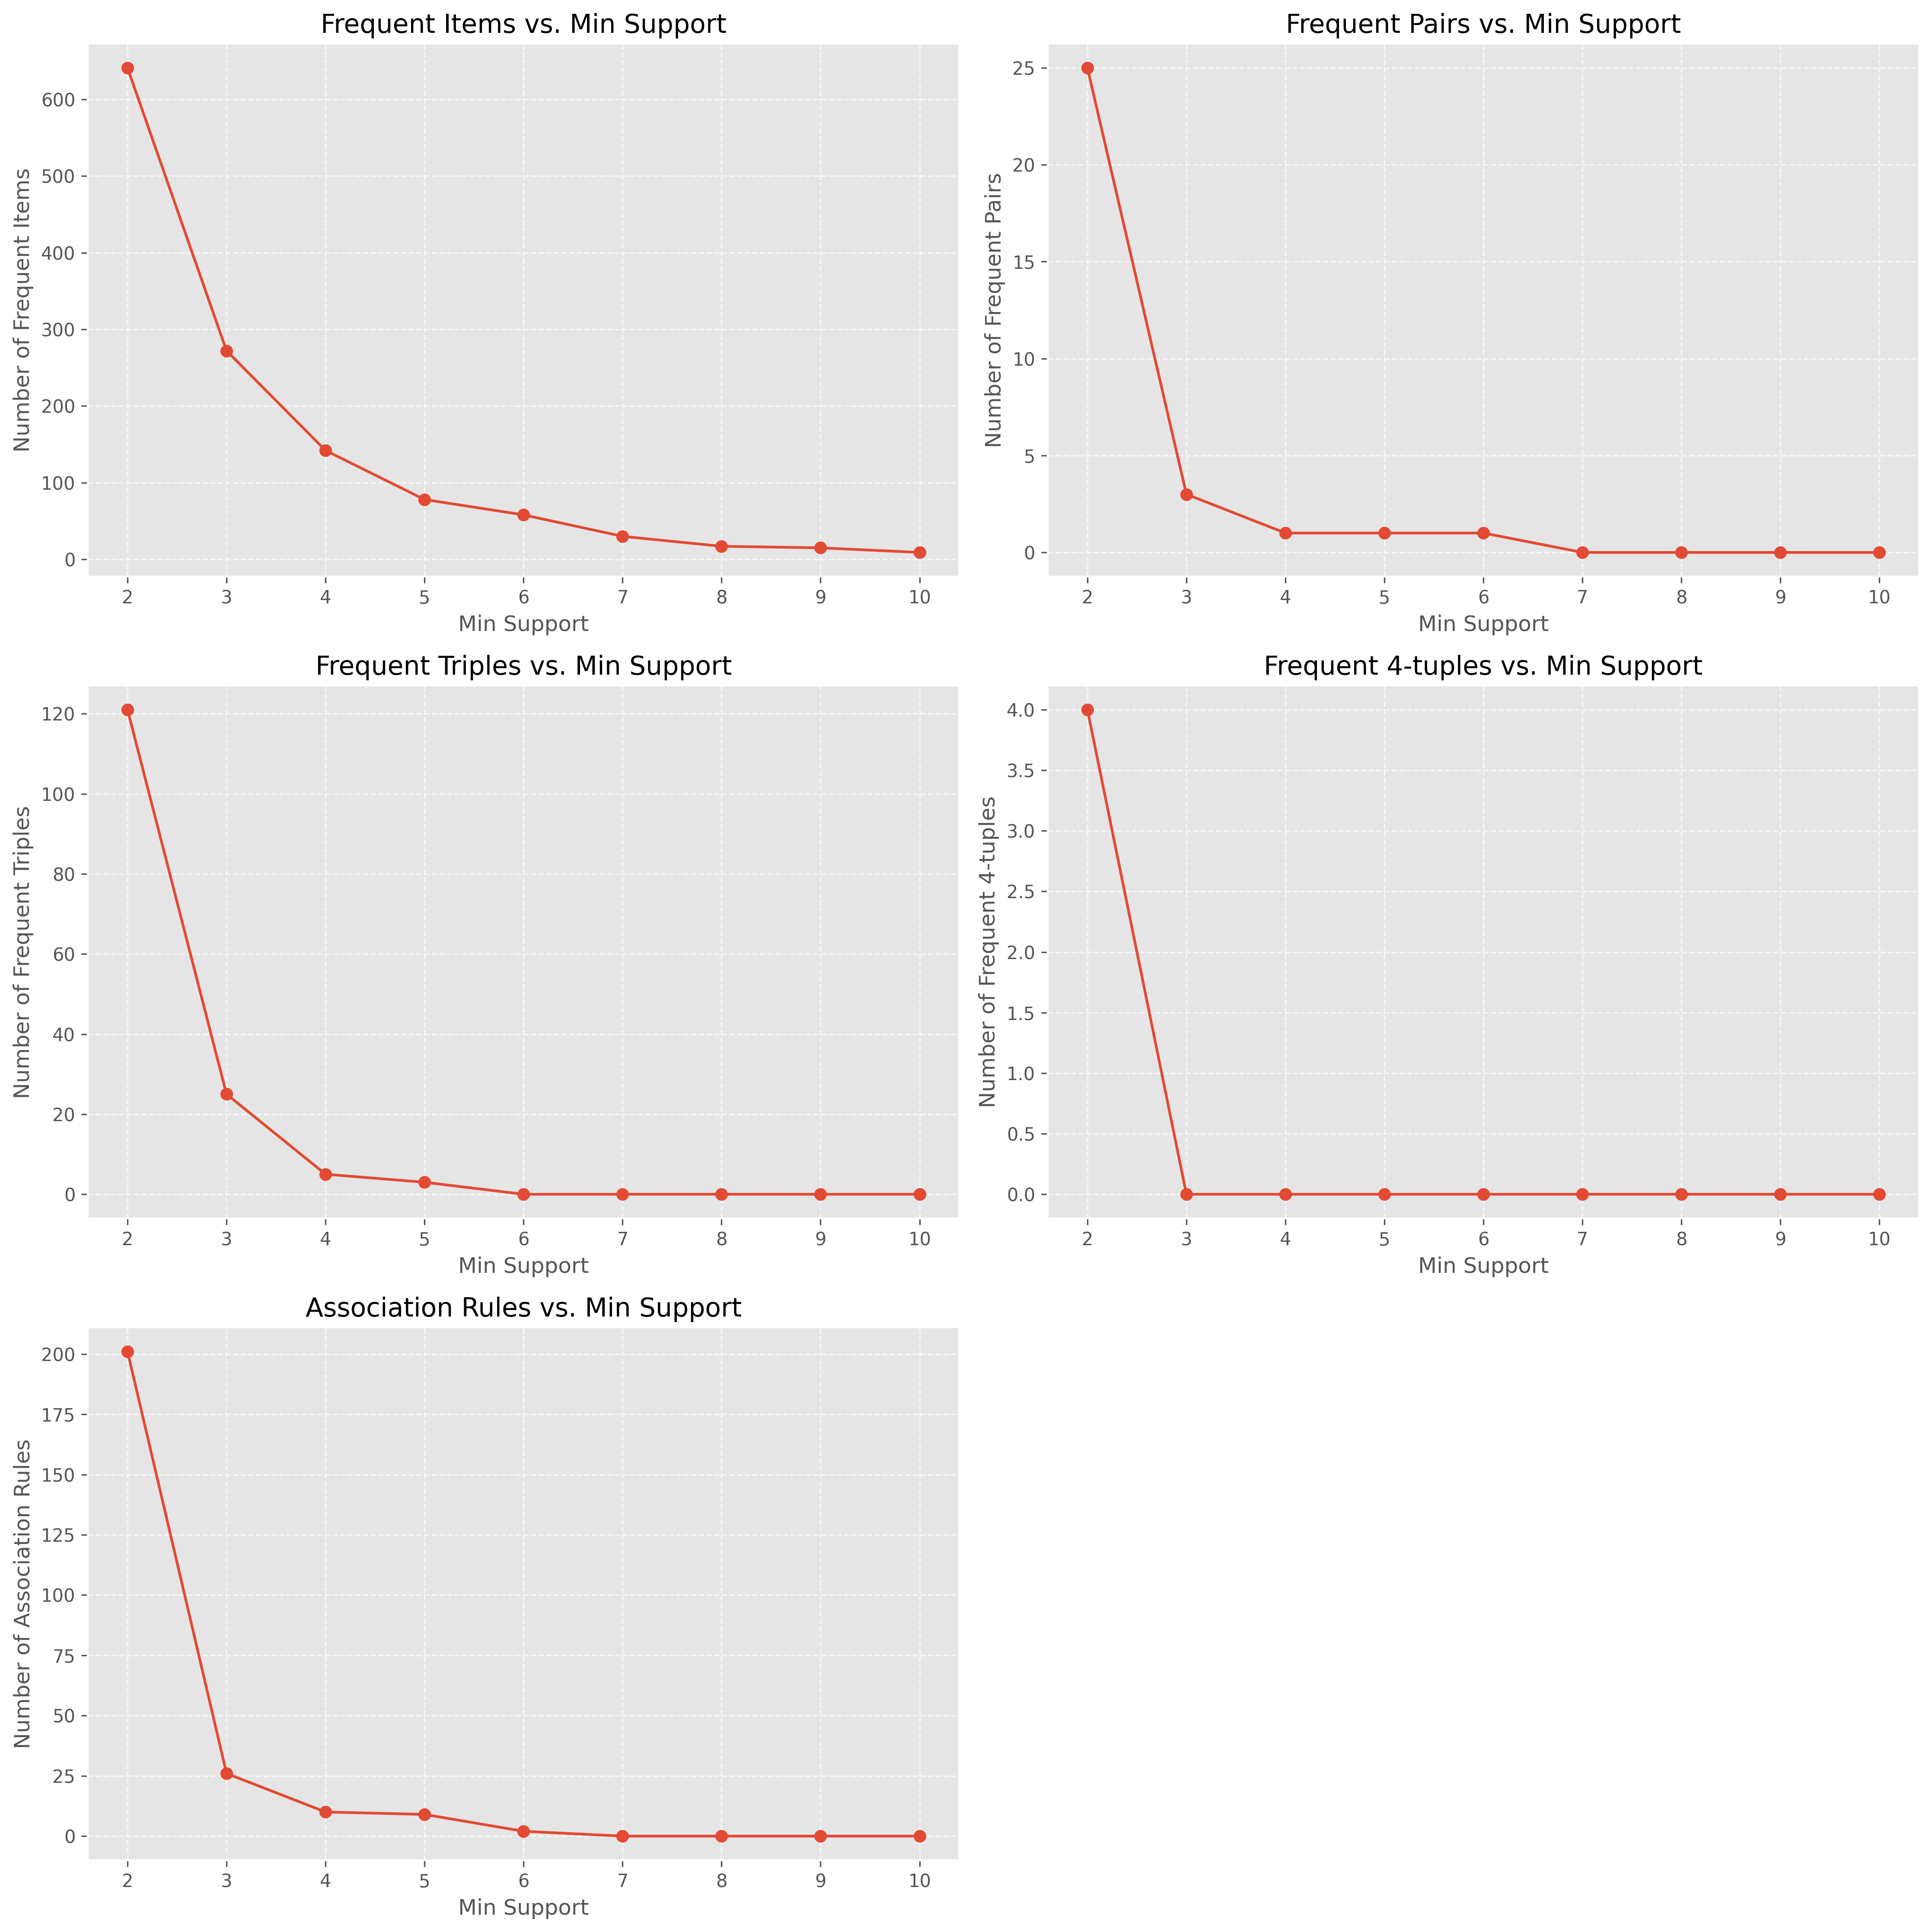

In [13]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

min_support_values = min_support_df.index
metrics = min_support_df.columns

fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize=(15, 15), dpi=300)
axes = axes.flatten() # Flatten 2D array to 1D for simpler indexing


for i, col_name in enumerate(metrics):
    ax = axes[i]
    ax.plot(min_support_values, min_support_df[col_name], marker='o')
    ax.set_title(f'{col_name} vs. Min Support')
    ax.set_xlabel('Min Support')
    ax.set_ylabel(f'Number of {col_name}')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xticks(min_support_values)

fig.delaxes(axes[5]) # Hide the unused subplot
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()